# Forecast Evolution Analysis (v2)
This notebook allows the user to interactively plot the "Linus plot" showing forecast evolution for a specific validity date. Tested on *IFS CF*, *AIFS Single*, *IFS ENS* and *AIFS ENS* forecasts.

## User Configuration Options

- **Parameter**: Select from dropdown list
- **Forecast Settings**: 
  - Validity date (calendar picker)
  - Validity time (dropdown)
  - Step interval (dropdown)
  - Maximum forecast days (slider)
- **Model Selection**:
  - **Predefined models**: Select from the list of known models (IFS Control, AIFS Single, etc.)
  - **Custom MARS models**: Define your own model by specifying MARS retrieval arguments (`class`, `type`, `stream`, `expver`) plus optional extra keys (`model`, `database`, `grid`, ...)
- **Geographic Area**: Select using the interactive map

### Model Selection Methods

#### Predefined Models
Select one or more models from the list on the left. These have pre-configured MARS retrieval settings and plot styles.

#### Custom MARS Models
Use the panel on the right to add a model by specifying its MARS retrieval arguments:
- **Name**: A display name for the model
- **class**: MARS class (e.g. `od`, `ai`, `rd`)
- **type**: Forecast type (`fc`, `cf`, `pf`)
- **stream**: Data stream (`oper`, `enfo`, ...)
- **expver**: Experiment version (optional)
- **Ensemble**: Tick if this is an ensemble (perturbed) forecast
- **Extra MARS arguments**: Add any additional key-value pairs (e.g. `model=aifs-single`, `database=...`, `grid=[0.25,0.25]`)

### Area Selection Methods

#### Polygon Selection
When drawing a polygon, the system creates a bounding box using the northernmost, westernmost, southernmost, and easternmost points of your selection.

#### Point Selection
When selecting a single point, the system creates a ±0.5° box around that location.

In [12]:
import os
import sys

def _find_notebook_dir():
    """Locate the directory containing this notebook (and the diag_evo package)."""
    candidates = []
    # 1. VS Code injects the notebook path into this variable
    vsc = globals().get("__vsc_ipynb_file__")
    if vsc:
        candidates.append(os.path.dirname(os.path.realpath(vsc)))
    # 2. Standard Jupyter: CWD is normally the notebook directory
    candidates.append(os.path.abspath(""))
    candidates.append(os.getcwd())
    for d in candidates:
        if os.path.isdir(os.path.join(d, "diag_evo")):
            return d
    raise FileNotFoundError(
        "Could not locate the diag_evo package. "
        "Make sure you run this notebook from within the diag_evo_v2 directory."
    )

notebook_dir = _find_notebook_dir()
sys.path.insert(0, notebook_dir)
base_path = os.path.join(notebook_dir, "data_files")

from diag_evo import (
    setup_interface,
    retrieve_and_store_data,
    plot_forecast_evolution,
    plot_forecast_evolution_static,
    setup_data_directories,
    get_area_string,
)

# Set up the interface and get the widgets dictionary
widgets_dict = setup_interface()

Please configure your forecast settings:


## Step 1 — Optional Configuration Overrides

You can programmatically override the widget selections before retrieving data.
Uncomment and adjust any of the lines below to set:

- **Area / point** — bounding box `[N, W, S, E]` or a single `[lat, lon]` point
- **Forecast range** — `max_days` and `step_interval`

In [3]:
# Optional: override configuration programmatically
#widgets_dict['config']['area_sub'] = [63.76772, 12.62371, 62.76772, 13.62371]
#widgets_dict['config']['point'] = [63.26772, 13.123712]
#widgets_dict['config']['max_days'] = 4
#widgets_dict['config']['step_interval'] = 12

## Step 2 — Optional Custom Models

Register additional models at runtime by specifying their MARS retrieval arguments.
Each model needs a unique **name**, a dict of MARS keys, and a plot colour.

In [ ]:
# Optional: add custom models programmatically instead of using the UI
# from diag_evo import register_custom_model
# register_custom_model(
#     name='AIFS_Experiment',
#     retrieval_args={
#         'class': 'rd',
#         'type': 'fc',
#         'stream': 'oper',
#         'expver': 'xxxx',
#         'model': 'some-model',
#     },
#     is_ensemble=False,
#     color='#ff6600'
# )

## Step 3 — Retrieve Data

Fetch observations, analysis, climatology, and model forecasts via MARS.
Results are cached locally so re-running the cell is fast.

In [13]:
plot_data = retrieve_and_store_data(widgets_dict, base_path)

Retrieving observations...
Retrieving new observation data...
Error retrieving observations: Metview error: STVL-> Failed! No output generated! Abort due to FAIL_ON_EMPTY_OUTPUT=YESPython - ERROR  - 20260225.124111 - Line 0 in 'PythonScript': STVL-> Failed! No output generated! Abort due to FAIL_ON_EMPTY_OUTPUT=YES

Retrieving analysis...
Retrieving analysis from MARS...
mars - WARN - 
mars - WARN - 
MIR environment variables:
MIR_CACHE_PATH={FILE?/ec/cache.1}/cache:{FILE?/ec/cache.2}/cache
MIR_LSM_NAMED=1km.climate.v013
Using MARS binary: /usr/local/apps/mars/versions/6.33.26.4/bin/mars.bin
mars - INFO   - 20260225.124112 - Welcome to MARS
mars - INFO   - 20260225.124112 - MARS_HOME=/usr/local/apps/mars/configs/prod
mars - INFO   - 20260225.124112 - MARS Client build stamp: 20250813133351
mars - INFO   - 20260225.124112 - MARS Client bundle version: 6.33.26.4
mars - INFO   - 20260225.124112 - package mars-client version: 6.33.26
mars - INFO   - 20260225.124112 - package mir version: 1

/etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/diag_evo/core.py:1347: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



## Step 4 — Interactive Plot (Plotly)

Generate the forecast evolution box-plot with hover info (bias, lead time, member index).
The plot is also exported as a standalone HTML file.

In [14]:
area_str = get_area_string(widgets_dict['config']['area_sub'])
date_str = widgets_dict['config']['valid_date'].strftime("%Y%m%d")
_, _, plot_dir = setup_data_directories(base_path, widgets_dict['config']['param'], area_str, date_str)
plot_data['data_df'].to_csv(f'{plot_dir}/plot_data.csv', index=False)

# Create the interactive plot
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/data_files/msl_N40.67048_W-73.69092_S39.67048_E-72.69092_20260223/plot_files/forecast_evolution_point_40.1705N_-73.1909E_20260223_1200_msl.html


## Step 5 — Static Plot (Matplotlib)

Percentile-box view (1/10/25/50/75/90/99) with an inset map showing the selected area or point.
Exported as a PNG file.

Static plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/data_files/msl_N40.67048_W-73.69092_S39.67048_E-72.69092_20260223/plot_files/forecast_evolution_static_point_40.1705N_-73.1909E_20260223_1200_msl.png


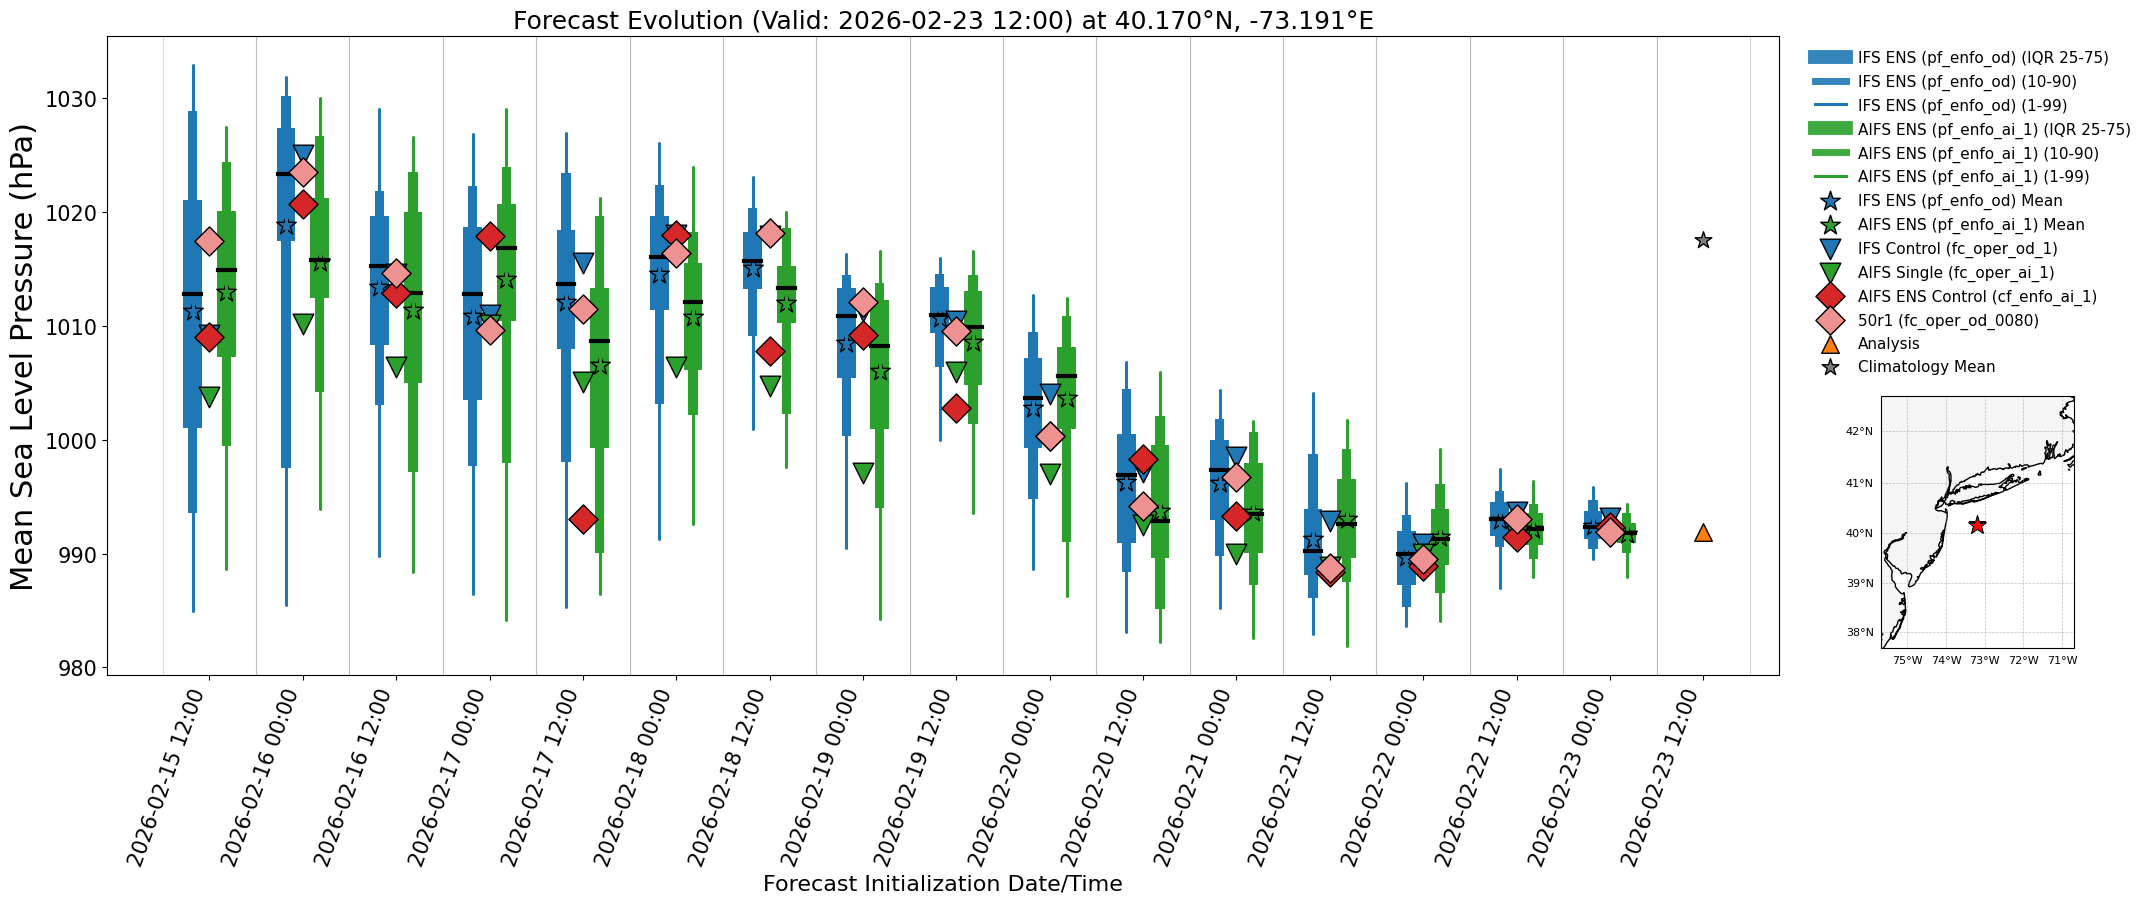

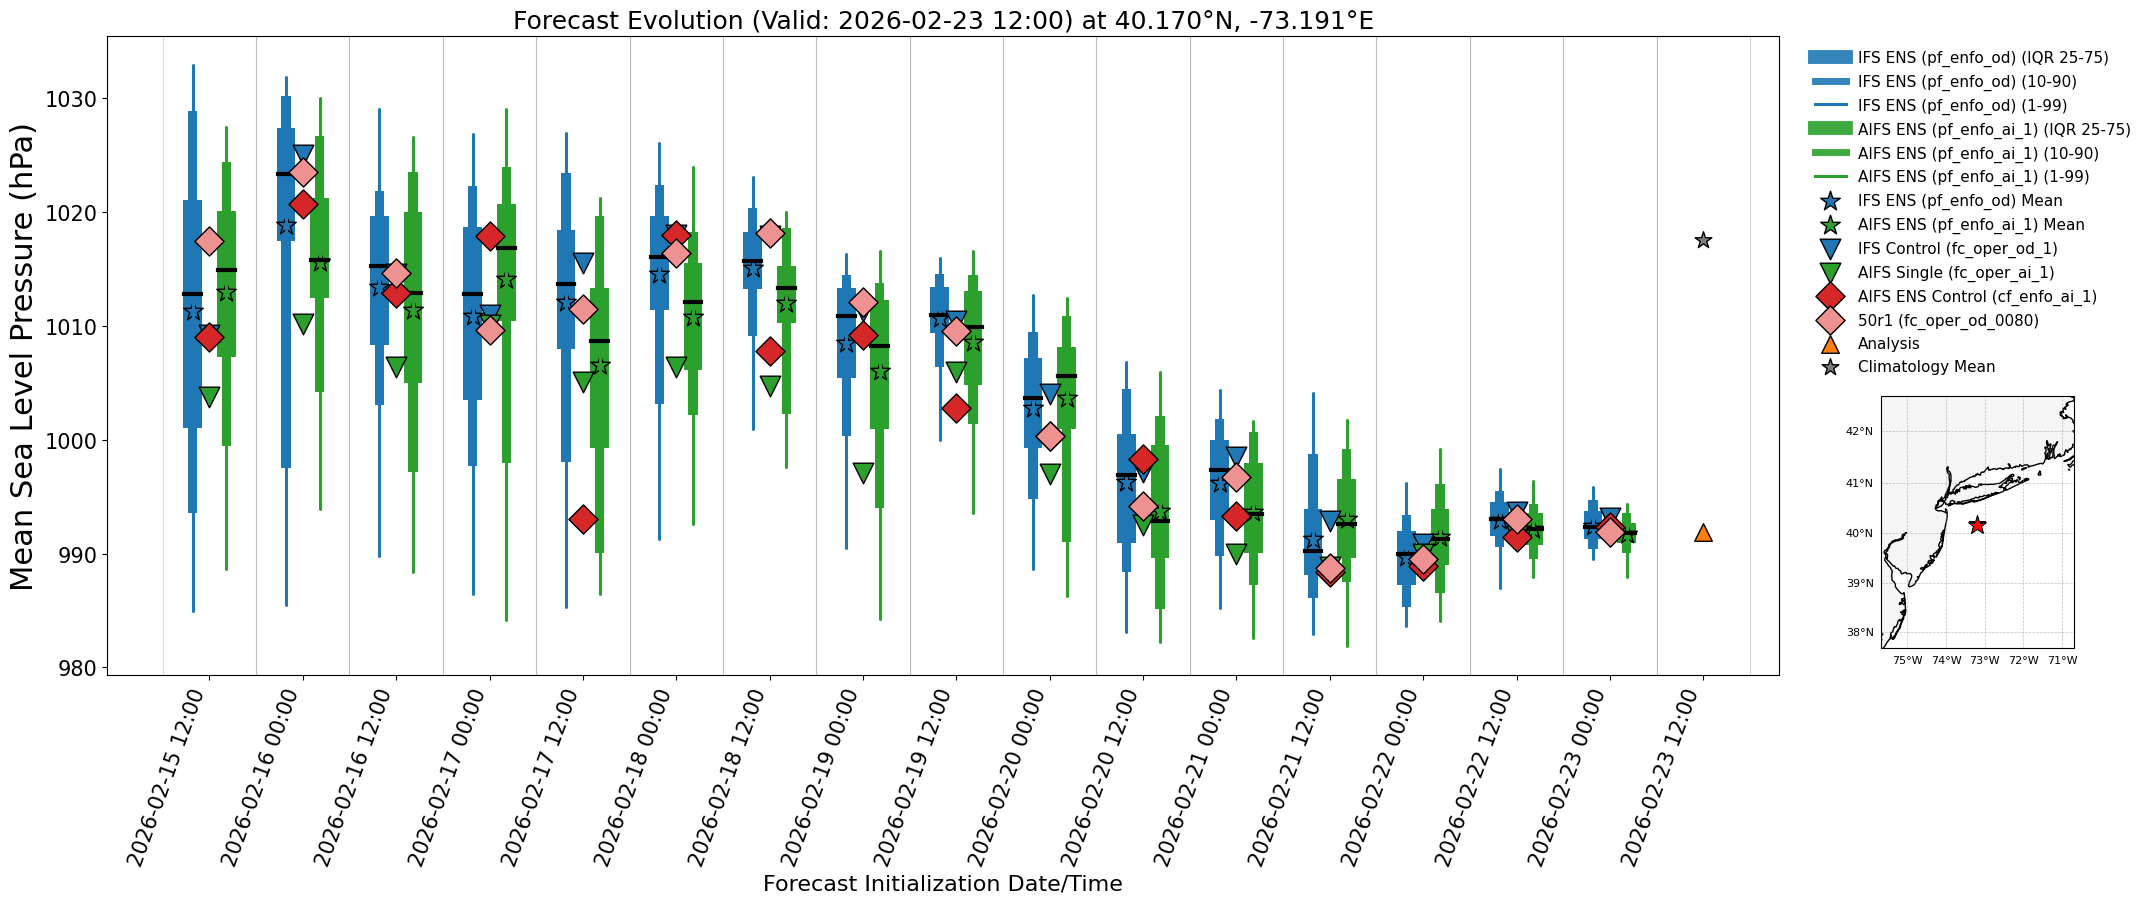

In [15]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

## Optional — Colour Overrides

Override the default plot colours per model before re-plotting.
Set `widgets_dict['config']['model_colors']` to a dict mapping model names to hex colours, then re-run a plot cell above.

In [18]:
from diag_evo import get_model_plot_settings

# Build a color map for all selected models
color_map = {}
for model_name in widgets_dict['model_widgets'].value:
    plot_cfg = get_model_plot_settings(model_name)
    color_map[model_name] = plot_cfg['color']

widgets_dict['config']['model_colors'] = color_map

In [21]:
widgets_dict['config']['model_colors']={'IFS Control': "#dd00ff",
 'AIFS Single': "#93190c",
 'AIFS ENS Control': '#00FF1E',
 'IFS ENS': "#1e837f",
 'AIFS ENS': "#2c32a0",
 '50r1': "#2ca098"
 }

Static plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/data_files/msl_N40.67048_W-73.69092_S39.67048_E-72.69092_20260223/plot_files/forecast_evolution_static_point_40.1705N_-73.1909E_20260223_1200_msl.png


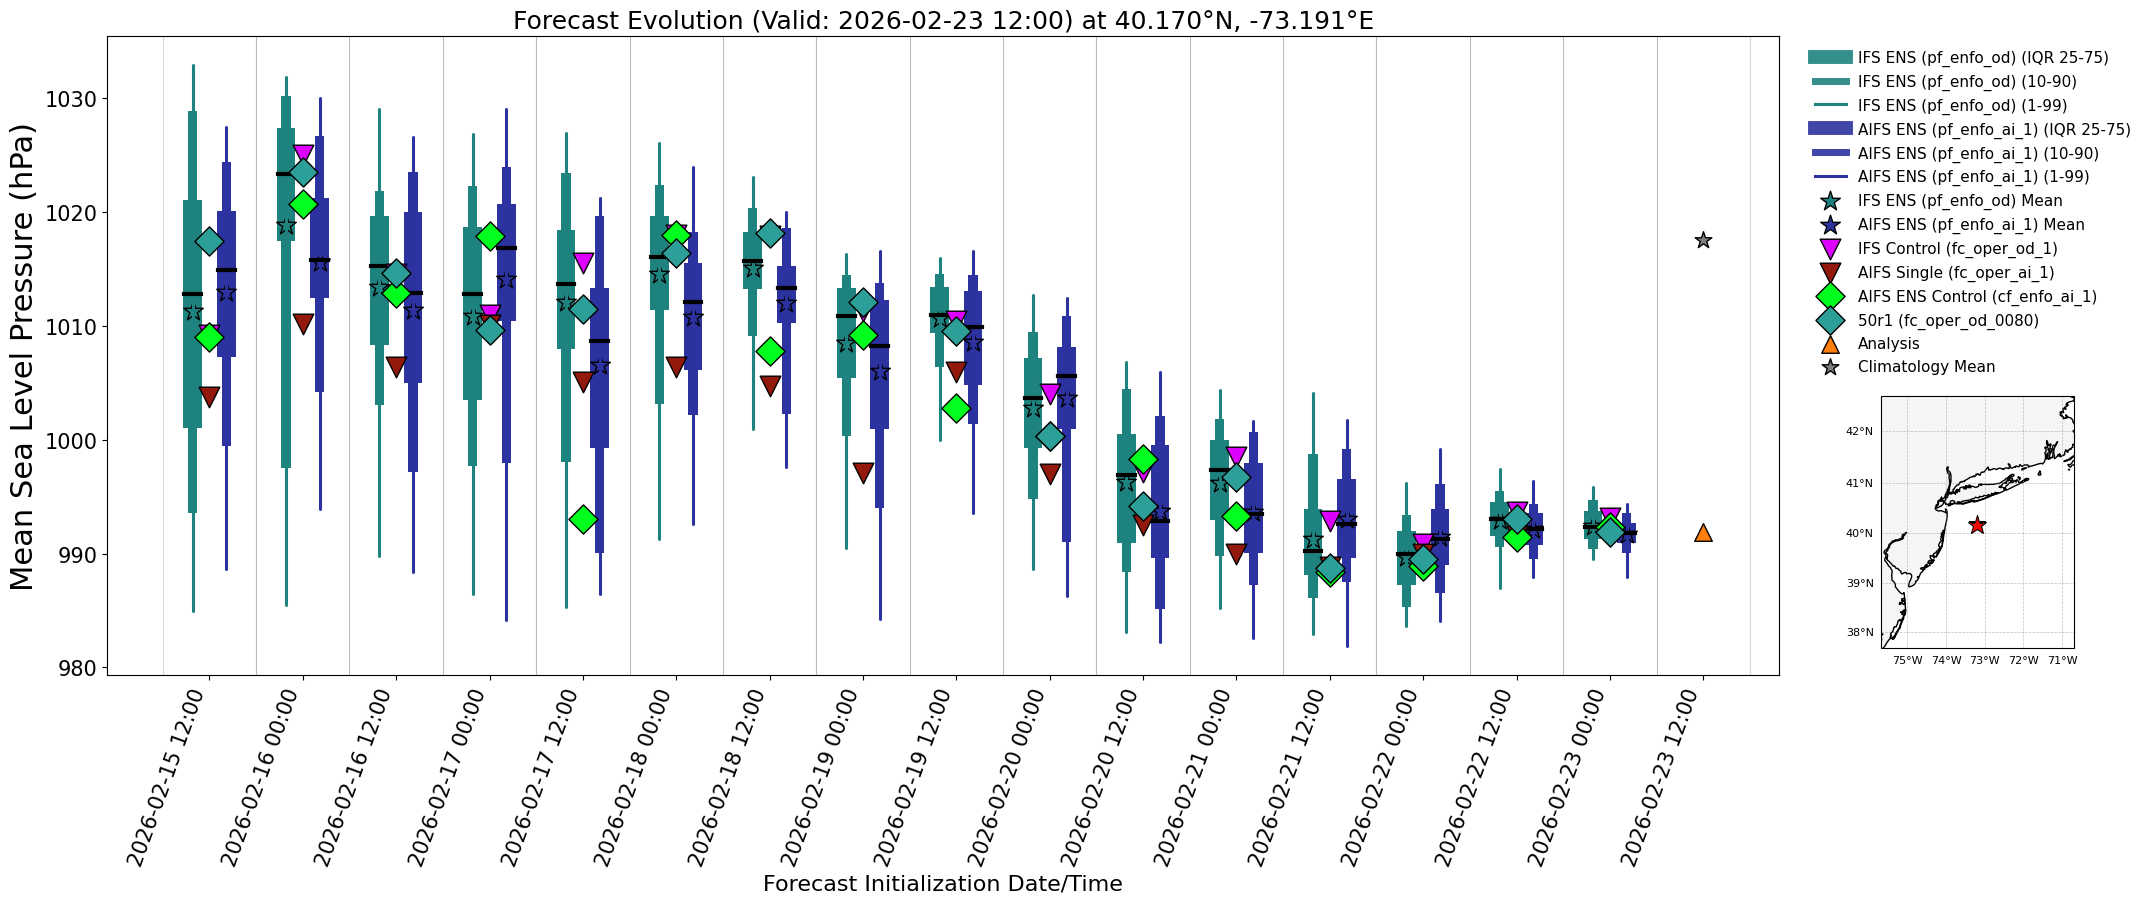

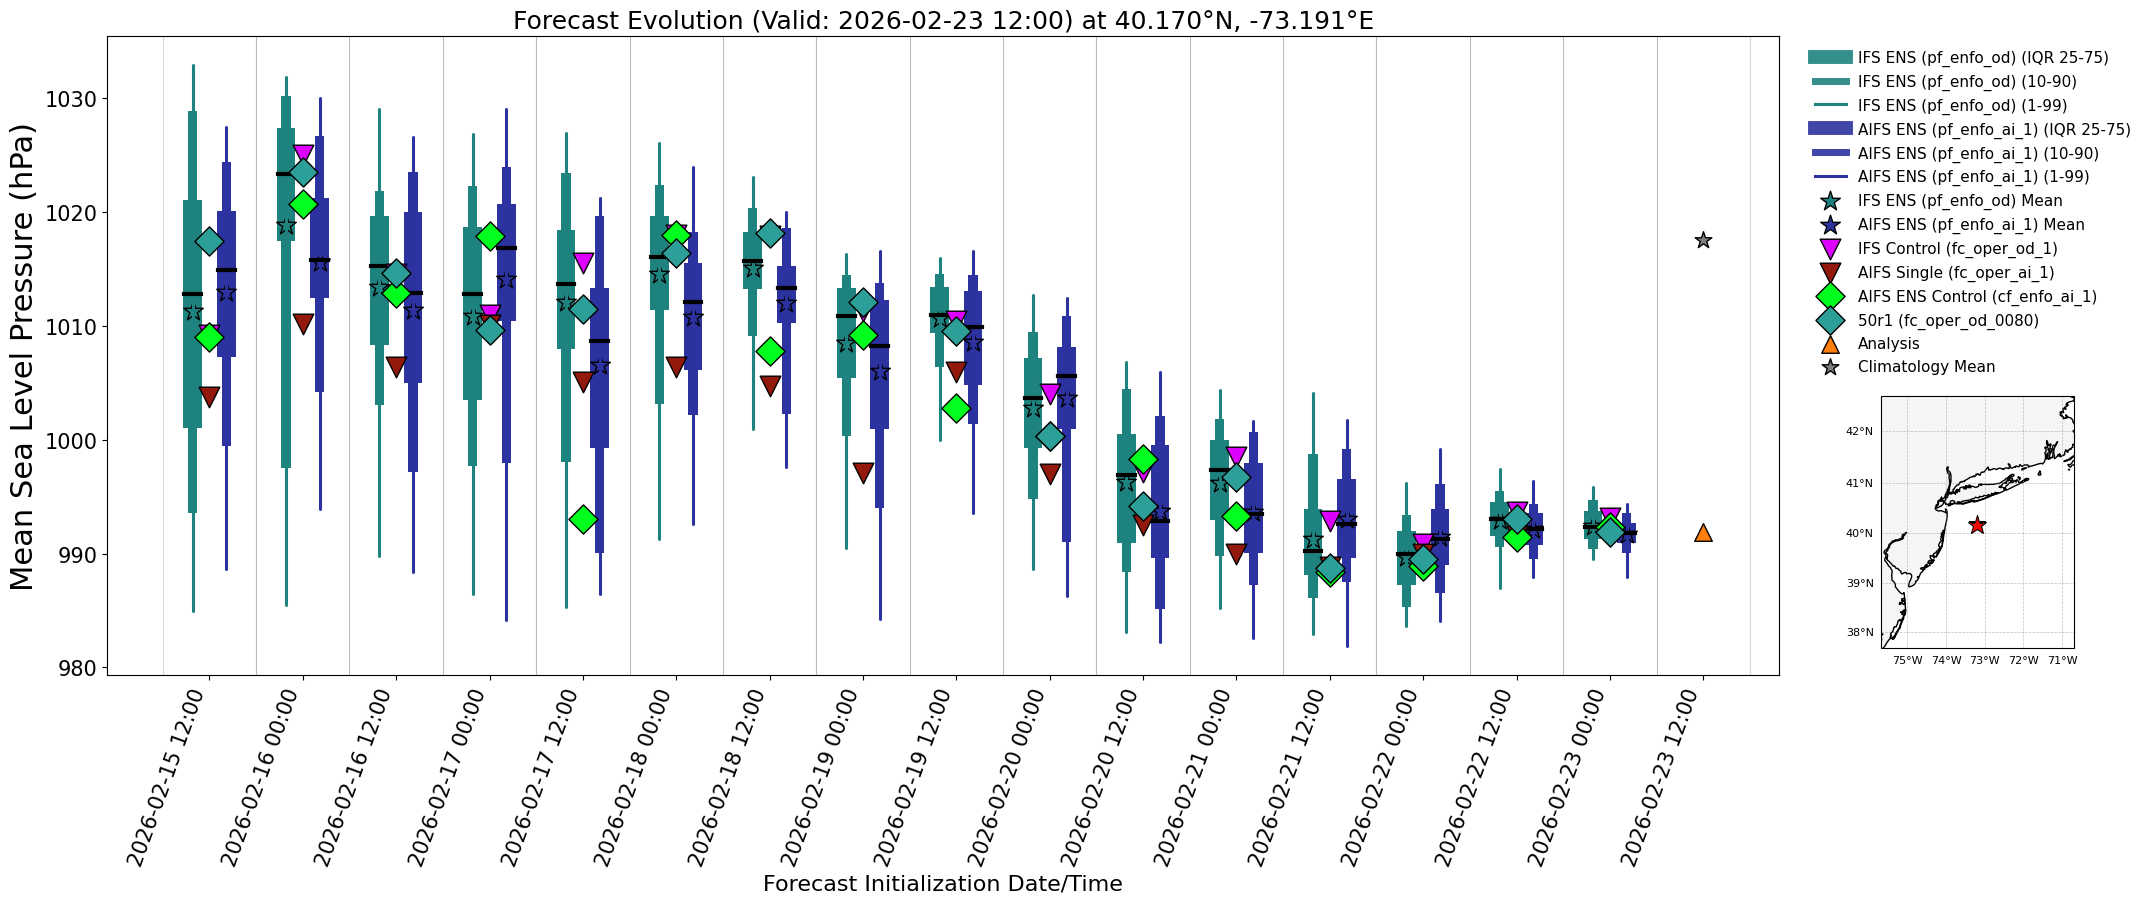

In [22]:
plot_forecast_evolution_static(plot_data, widgets_dict, plot_dir, export_png=True)

In [23]:
plot_forecast_evolution(plot_data, widgets_dict, plot_dir, export_html=True)

Plot exported to: /etc/ecmwf/nfs/dh1_perm_a/ecm3468/for_Balazs/diag_evo_v2/data_files/msl_N40.67048_W-73.69092_S39.67048_E-72.69092_20260223/plot_files/forecast_evolution_point_40.1705N_-73.1909E_20260223_1200_msl.html
